In [1]:
# 24W Female
import pandas as pd

In [2]:
# Good resource for TF - target genes: https://www.grnpedia.org/trrust/key_regulator/015fc0d93c.php

In [3]:
quadrant_0_female = pd.read_csv('../../data/taPVAT_Adipocytes_Brown_Female_MetaDEGs_Quadrant_0.csv')
quadrant_3_female = pd.read_csv('../../data/taPVAT_Adipocytes_Brown_Female_MetaDEGs_Quadrant_3.csv')

In [5]:
quadrant_0_list= list(quadrant_0_female['gene_id'])
quadrant_3_list = list(quadrant_3_female['gene_id'])

In [9]:
quadrant_0_list.__len__()

63

In [10]:
quadrant_3_list.__len__()

25

In [6]:
combined_list = set(quadrant_0_list + quadrant_3_list)
combined_list_capitalized = [gene.upper() for gene in combined_list]


In [11]:
combined_list.__len__()

88

In [7]:
# Remove genes starting with 'ENSRN' and print them
to_remove = [gene for gene in combined_list_capitalized if gene.startswith('ENSRN')]
to_remove2 = [gene for gene in combined_list_capitalized if gene.startswith('LOC')]
to_remove3 = [gene for gene in combined_list_capitalized if gene.startswith('AABR')]
for gene in to_remove:
    print(f'Removed gene: {gene}')
    combined_list_capitalized.remove(gene)
for gene in to_remove2:
    print(f'Removed gene: {gene}')
    combined_list_capitalized.remove(gene)
for gene in to_remove3:
    print(f'Removed gene: {gene}')
    combined_list_capitalized.remove(gene)

Removed gene: ENSRNOG00000066257
Removed gene: ENSRNOG00000069803
Removed gene: ENSRNOG00000067467
Removed gene: ENSRNOG00000038299
Removed gene: ENSRNOG00000066171
Removed gene: ENSRNOG00000063301
Removed gene: ENSRNOG00000070819
Removed gene: ENSRNOG00000064141
Removed gene: LOC100363472


In [12]:
combined_list_capitalized.__len__()

79

In [13]:
print(*combined_list_capitalized, sep="\n")

HTR2B
PPP2R2C
CAR2
PPP1R3C
MYC
TMEM38B
LSM8
ZFP697
DCBLD2
ABHD5
CYCT
IRS1
CYP4A2
ADAMTS15
TCIM
MAGED1
TMEFF2
TMEM182
LRIG3
MAP2K6
SGMS2
CD6
EHHADH
ALB
CITED2
IRGM
IPMK
TIFA
FUT10
SPOCK1
GREB1
TTN
GLP2R
NEK10
METTL7A
MROH7
TBC1D8
TRHDE
CKB
PCDH9
PROS1
DIO2
SHC3
NDUFAF5
SAV1
SHANK2
GABRG3
OR8G20
DUSP4
MIGA1
ZFP639
KLHL35
VCAM1
SFRP1
CYP2E1
CHSY3
SLC25A21
ROBO2
SLC25A18
ARMCX3
ANKS1B
GADD45A
ZFP868
TG
DUSP6
AGBL1
MUTYH
SOCS2
HLX
MEGF11
CPA2
FAM151A
GPR88
TXN1
CCDC3
NFATC4
ACSL4
NID1
CXCL14


# I copied and pasted the list of genes into CHEA3 results and selected the Mean Rank tab. The Mean Rank selection criteria is the best performing criteria method by their Benchmarking predictions (Figure 1).
## https://maayanlab.cloud/chea3/#top

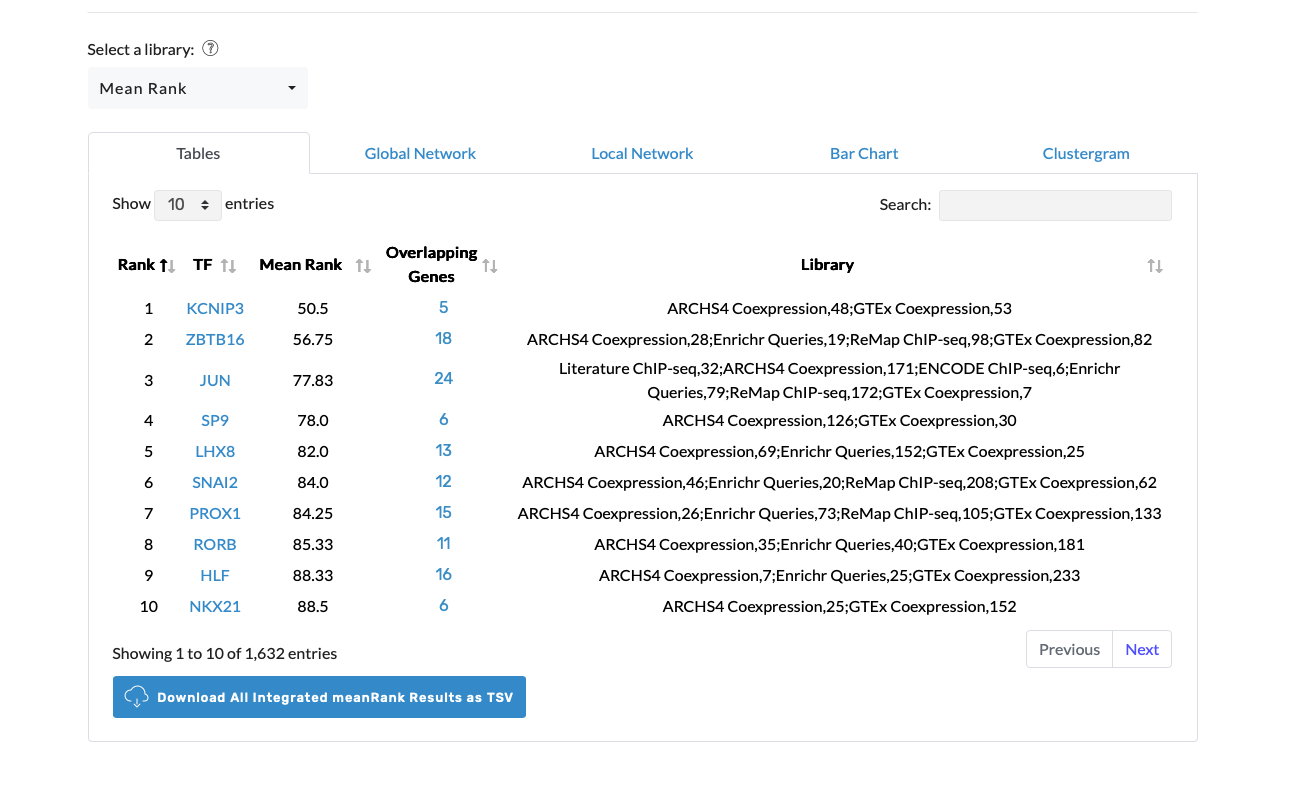

In [6]:

df_Adipocytes_Brown = pd.read_csv('../../predictions/gene_scores/August18_10_21_gene_scores_Adipocytes_Brown_24W_F.csv')


In [7]:

df_Adipocytes_Brown


,Unnamed: 0,Gene,Score
0,0,1700066B19Rik,0.002766
1,1,6330411D24Rik,-0.002988
2,2,A3galt2,0.004607
3,3,AABR07001512.1,-0.001169
4,4,AABR07002467.1,-0.002494
...,...,...,...
4995,4995,Zpbp2,-0.012677
4996,4996,Zpld1,-0.000383
4997,4997,Zscan10,0.002938
4998,4998,Zswim6,0.366887


In [8]:
df_Adipocytes_Brown = df_Adipocytes_Brown[~df_Adipocytes_Brown['Gene'].str.startswith('Mt-')] # Removed mitochondrial genes
df_Adipocytes_Brown = df_Adipocytes_Brown[~df_Adipocytes_Brown['Gene'].str.startswith('AABR')]
df_Adipocytes_Brown = df_Adipocytes_Brown[~df_Adipocytes_Brown['Gene'].str.startswith('ENSRN')]

In [9]:
pval = 1.0

In [10]:
df_Adipocytes_Brown[df_Adipocytes_Brown['Gene'].str.startswith('Creb')]

,Unnamed: 0,Gene,Score
939,939,Creb3,0.055827
940,940,Creb3l1,-0.039237
941,941,Creb3l4,0.017940
942,942,Creb5,-0.264325


In [11]:
# Add a new column with the absolute value of the score

df_Adipocytes_Brown['abs_score'] = df_Adipocytes_Brown['Score'].abs()


# Sort by absolute score

top_abs_Adipocytes_Brown = df_Adipocytes_Brown.sort_values('abs_score', ascending=False).head(50)



In [14]:
significant_quad_3 = quadrant_3_female[quadrant_3_female['pval']<pval]
significant_quad_3 = significant_quad_3[~significant_quad_3['gene_id'].str.startswith('Mt-')]
significant_quad_3 = significant_quad_3[~significant_quad_3['gene_id'].str.startswith('AABR')]
significant_quad_3 = significant_quad_3[~significant_quad_3['gene_id'].str.startswith('ENSRN')]


In [15]:
significant_quad_3

,gene_id,gene_id.1,celltype,group,sub_id,sub_id_2,log2FoldChange_Control,lfcSE_Control,log2FoldChange_HF,lfcSE_HF,log2FC_diff,se_delta,z,pval,padj_diff
0,Cyct,Cyct,Adipocytes_Brown,time,Control,F,-6.150365,1.222868,-1.237673,0.877009,-4.912692,1.504843,-3.264588,0.001096,0.836679
1,Slc25a21,Slc25a21,Adipocytes_Brown,time,Control,F,-2.988795,0.949185,-0.615209,0.403658,-2.373587,1.031451,-2.301211,0.021380,0.999994
2,Pcdh9,Pcdh9,Adipocytes_Brown,time,Control,F,-1.991190,0.592345,0.263275,0.466573,-1.727915,0.754032,-2.291568,0.021931,0.999994
3,Slc25a18,Slc25a18,Adipocytes_Brown,time,Control,F,-1.999643,0.544848,0.505825,0.774343,-1.493818,0.946819,-1.577723,0.114629,0.999994
4,Ppp1r3c,Ppp1r3c,Adipocytes_Brown,time,Control,F,-1.710831,0.355645,0.379988,0.413672,-1.330843,0.545534,-2.439524,0.014707,0.999994
5,Pros1,Pros1,Adipocytes_Brown,time,Control,F,-2.569071,0.305573,-1.255795,0.341024,-1.313277,0.457900,-2.868043,0.004130,0.999994
6,Greb1,Greb1,Adipocytes_Brown,time,Control,F,-1.325145,0.283706,0.018654,0.318161,-1.306491,0.426281,-3.064856,0.002178,0.867083
7,Zfp697,Zfp697,Adipocytes_Brown,time,Control,F,-1.535469,0.481192,-0.251208,0.536773,-1.284261,0.720882,-1.781512,0.074829,0.999994
8,Irgm,Irgm,Adipocytes_Brown,time,Control,F,-2.057134,0.673128,0.795017,0.616239,-1.262117,0.912607,-1.382981,0.166671,0.999994
9,Dcbld2,Dcbld2,Adipocytes_Brown,time,Control,F,-1.240205,0.510962,0.019257,0.597820,-1.220948,0.786429,-1.552522,0.120537,0.999994


In [16]:
significant_quad_0 = quadrant_0_female[quadrant_0_female['pval']<pval]
significant_quad_0 = significant_quad_0[~significant_quad_0['gene_id'].str.startswith('Mt-')]
significant_quad_0 = significant_quad_0[~significant_quad_0['gene_id'].str.startswith('AABR')]
significant_quad_0 = significant_quad_0[~significant_quad_0['gene_id'].str.startswith('ENSRN')]




In [17]:
genes_that_went_up_in_HF = list(significant_quad_0['gene_id'])
genes_that_went_down_in_control = list(significant_quad_3['gene_id'])

In [18]:
df_Adipocytes_Brown['Score'].sort_values(ascending=False)

1038    2.150542
2878    2.145696
4542    1.948913
2613    1.829507
4781    1.733362
          ...   
124    -0.871221
721    -0.896057
119    -1.301337
1774   -1.349035
109    -1.481022
Name: Score, Length: 4531, dtype: float64

In [19]:
mask = (df_Adipocytes_Brown['Score'] > 0) & \
       (df_Adipocytes_Brown['Gene'].isin(genes_that_went_up_in_HF) |
        df_Adipocytes_Brown['Gene'].isin(genes_that_went_down_in_control))

df_filtered = df_Adipocytes_Brown[mask]

In [20]:
df_filtered.sort_values('Score',ascending=False)

,Unnamed: 0,Gene,Score,abs_score
4545,4545,Tcim,0.238535,0.238535
4339,4339,Socs2,0.198288,0.198288
3185,3185,Nid1,0.078554,0.078554
559,559,Car2,0.076205,0.076205
337,337,Armcx3,0.031404,0.031404
4383,4383,Spock1,0.025757,0.025757
1100,1100,Dio2,0.023794,0.023794
4809,4809,Ttn,0.021228,0.021228
806,806,Chsy3,0.010172,0.010172
148,148,Adamts15,0.008127,0.008127


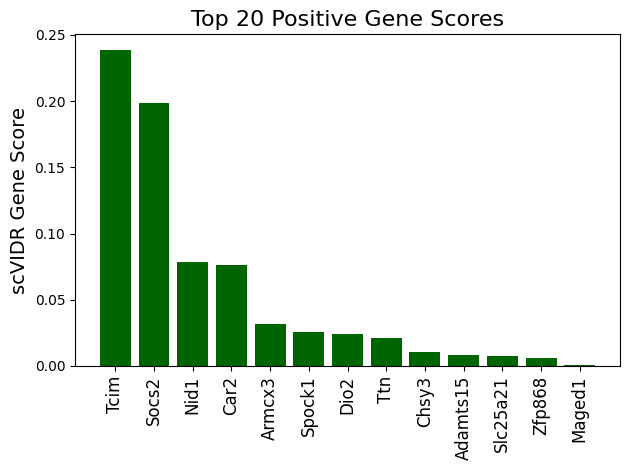

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming df_Adipocytes_Brown is already loaded and contains 'Gene' and 'Score' columns

# Top 20 most positive gene scores
top_pos = df_filtered.sort_values('Score', ascending=False).head(30)

plt.figure(dpi=100)
plt.bar(top_pos['Gene'], top_pos['Score'], color='darkgreen')
plt.xticks(rotation=90, fontsize=12)
plt.ylabel("scVIDR Gene Score", fontsize=14)
plt.title("Top 20 Positive Gene Scores", fontsize=16)
plt.tight_layout()
#plt.savefig("../figures/Top20PositiveGeneScores_24W_Brown_Adipocytes_Both.svg", bbox_inches="tight")
plt.show()




# Genes that decreased in HF

In [22]:
quadrant_1_female = pd.read_csv('../../data/taPVAT_Adipocytes_Brown_Female_MetaDEGs_Quadrant_1.csv')
quadrant_2_female = pd.read_csv('../../data/taPVAT_Adipocytes_Brown_Female_MetaDEGs_Quadrant_2.csv')
significant_quad_1 = quadrant_1_female[quadrant_1_female['pval']<pval]
significant_quad_1 = significant_quad_1[~significant_quad_1['gene_id'].str.startswith('Mt-')]
significant_quad_1 = significant_quad_1[~significant_quad_1['gene_id'].str.startswith('AABR')]
significant_quad_1 = significant_quad_1[~significant_quad_1['gene_id'].str.startswith('ENSRN')]


significant_quad_2 = quadrant_2_female[quadrant_2_female['pval']<pval]
significant_quad_2 = significant_quad_2[~significant_quad_2['gene_id'].str.startswith('Mt-')]
significant_quad_2 = significant_quad_2[~significant_quad_2['gene_id'].str.startswith('AABR')]
significant_quad_2 = significant_quad_2[~significant_quad_2['gene_id'].str.startswith('ENSRN')]

genes_that_went_up_in_control = list(significant_quad_1['gene_id'])
genes_that_went_down_in_hf = list(significant_quad_2['gene_id'])


mask2 = (df_Adipocytes_Brown['Score'] > 0) & \
       (df_Adipocytes_Brown['Gene'].isin(genes_that_went_up_in_control) |
        df_Adipocytes_Brown['Gene'].isin(genes_that_went_down_in_hf))

df_filtered2 = df_Adipocytes_Brown[mask2]

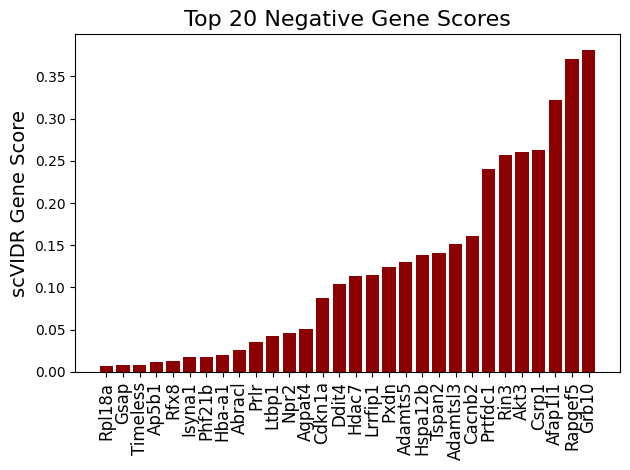

In [23]:
#Top 20 most negative gene scores

top_neg = df_filtered2.sort_values('Score', ascending=True).head(30)

plt.figure(dpi=100) 
plt.bar(top_neg['Gene'], top_neg['Score'], color='darkred') 
plt.xticks(rotation=90, fontsize=12) 
plt.ylabel("scVIDR Gene Score", fontsize=14) 
plt.title("Top 20 Negative Gene Scores", fontsize=16)

plt.tight_layout() #plt.savefig("../figures/Top20NegativeGeneScores_24W_Brown_Adipocytes_Both.svg", bbox_inches="tight") 
plt.show()

In [ ]:
import gseapy as gp
import pandas as pd


# Rank by absolute score
df_Adipocytes_Brown['abs_score'] = df_Adipocytes_Brown['Score'].abs()
top_genes = df_Adipocytes_Brown.sort_values('abs_score', ascending=False).head(100)

# Extract gene list
glist = top_genes['Gene'].tolist()

glist_top_increase = df_Adipocytes_Brown.sort_values('Score', ascending=False).head(100)
glist_top_increase = glist_top_increase['Gene'].tolist()
# Enrichment analysis
enr = gp.enrichr(
    gene_list=glist_top_increase,
    gene_sets= ["GO_Biological_Process_2023"], #["WikiPathways_2024_Mouse"],
    organism='Mouse',
    #description='adipocytes_brown_top100',
    #outdir='results/enrichr_adipocytes_brown',
    cutoff=0.5  # relaxed cutoff
)

gp.plot.barplot(enr.results,title='Enrichr Analysis of Gene Scores \n for Genes that Increase Along Perturbation Axis',fs = 8, top_term = 20)
#plt.savefig("../figures/4B.svg", bbox_inches = "tight")
# enr.results.head(10)

In [ ]:
import gseapy as gp
import pandas as pd

# Load gene scores
df_Adipocytes_Brown = pd.read_csv('../predictions/gene_scores/gene_scores_Adipocytes_Brown_8W.csv')

# Rank by absolute score
df_Adipocytes_Brown['abs_score'] = df_Adipocytes_Brown['Score'].abs()

glist_top_decrease = df_Adipocytes_Brown.sort_values('Score', ascending=True).head(100)
glist_top_decrease = glist_top_decrease['Gene'].tolist()

print(glist_top_decrease)
# Enrichment analysis
enr = gp.enrichr(
    gene_list=glist_top_decrease,
    gene_sets=["GO_Biological_Process_2023"], #["GO_Biological_Process_2023"],
    organism='Mouse',
    #description='adipocytes_brown_top100',
    #outdir='results/enrichr_adipocytes_brown',
    cutoff=0.5  # relaxed cutoff
)
enr.results.head(10)
gp.plot.barplot(enr.results,title='Enrichr Analysis of Gene Scores \n for Genes that Decrease Along Perturbation Axis',fs = 8, top_term = 20)
#plt.savefig("../figures/4B.svg", bbox_inches = "tight")




In [ ]:
gp.plot.barplot(enr.results,title='Enrichr Analysis of Gene Scores \n for Bottom ',fs = 8, top_term = 20)

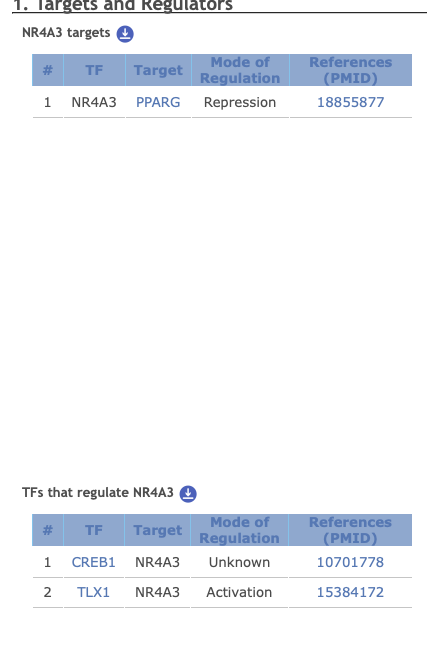

In [ ]:
# 1	NR4A1	BABAM2	Repression	22159226
# 2	NR4A1	CCNA2	Repression	12842839
# 3	NR4A1	CDKN1B	Activation	12842839
# 4	NR4A1	CYP11A1	Unknown	20083153
# 5	NR4A1	CYP17A1	Unknown	20083153
# 6	NR4A1	E2F1	Activation	12947120
# 7	NR4A1	FASLG	Unknown	14563113
# 8	NR4A1	HSD3B2	Activation	15666793
# 9	NR4A1	HSD3B2	Unknown	15208301; 20083153; 23874725
# 10	NR4A1	MDM2	Repression	17139261
# 11	NR4A1	MMP2	Activation	22551568
# 12	NR4A1	RNF7	Repression	22159226
# 13	NR4A1	SERPINE1	Unknown	12506026
# 14	NR4A1	STAR	Unknown	20083153
# 15	NR4A1	TIMP2	Activation	22551568
# 16	NR4A1	TNF	Repression	19213954




### Regulators of NR4A1:
# TFs that regulate NR4A1  
# #	TF	Target	Mode of Regulation	References
# (PMID)
# 1	HDAC7	NR4A1	Unknown	15623513
# 2	HIF1A	NR4A1	Activation	14729605
# 3	MEF2C	NR4A1	Repression	18079734
# 4	PML	NR4A1	Repression	12032831
# 5	SP1	NR4A1	Unknown	8961265

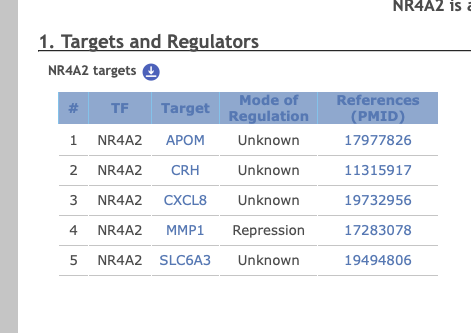

In [ ]:
glist_top_increase